1.IMPORT LIBRARIES

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

2.LOAD DATASET

In [3]:
df = pd.read_csv("../data/indoorAir.csv")

print(df.head())

print(df.shape)


   id  station_id      station_name   timestamp  scd41_co2  scd41_temperature  \
0   1           1  station_room_233  1731517076      488.0          22.951857   
1   2           1  station_room_233  1731517137      485.0          22.335011   
2   3           1  station_room_233  1731517199      477.0          22.353704   
3   4           1  station_room_233  1731517263      474.0          22.417792   
4   5           1  station_room_233  1731517325      473.0          22.556649   

   scd41_humidity  ens160_eco2  ens160_tvoc  ens160_aqi  ...  svm41_humidity  \
0       36.897277          418           32           1  ...       34.060001   
1       38.185119          414           30           1  ...       34.209999   
2       38.400268          443           43           1  ...       34.180000   
3       38.269042          406           26           1  ...       34.130001   
4       37.971496          416           31           1  ...       34.240001   

   svm41_nox_index  svm41_voc_in

3.HANDLE TIMESTAMP

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df = df.sort_values(by='timestamp')

df.set_index('timestamp', inplace=True)

print(df.head())

                     id  station_id      station_name  scd41_co2  \
timestamp                                                          
2024-11-13 16:57:56   1           1  station_room_233      488.0   
2024-11-13 16:58:57   2           1  station_room_233      485.0   
2024-11-13 16:59:59   3           1  station_room_233      477.0   
2024-11-13 17:01:03   4           1  station_room_233      474.0   
2024-11-13 17:02:05   5           1  station_room_233      473.0   

                     scd41_temperature  scd41_humidity  ens160_eco2  \
timestamp                                                             
2024-11-13 16:57:56          22.951857       36.897277          418   
2024-11-13 16:58:57          22.335011       38.185119          414   
2024-11-13 16:59:59          22.353704       38.400268          443   
2024-11-13 17:01:03          22.417792       38.269042          406   
2024-11-13 17:02:05          22.556649       37.971496          416   

                     ens1

4.FEATURE ENGINEERING

In [6]:
hour = df.index.hour
dayofweek = df.index.dayofweek

df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * dayofweek / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * dayofweek / 7)

df['is_weekend'] = (dayofweek >= 5).astype(int)

5.SELECT FEATURES

In [7]:
FEATURES = [
    'ens160_aqi',
    'ens160_tvoc',
    'bme688_gas_resistance',
    'bme688_pressure',
    'scd41_temperature',
    'scd41_humidity',
    'scd41_co2',
    'hour_sin',
    'hour_cos',
    'dayofweek_sin',
    'dayofweek_cos',
    'is_weekend',
    'station_id'
]

TARGET = 'scd41_co2'

df = df[FEATURES]

print(df.head())

print(df.shape)

                     ens160_aqi  ens160_tvoc  bme688_gas_resistance  \
timestamp                                                             
2024-11-13 16:57:56           1           32                    NaN   
2024-11-13 16:58:57           1           30                    NaN   
2024-11-13 16:59:59           1           43                    NaN   
2024-11-13 17:01:03           1           26                    NaN   
2024-11-13 17:02:05           1           31                    NaN   

                     bme688_pressure  scd41_temperature  scd41_humidity  \
timestamp                                                                 
2024-11-13 16:57:56              NaN          22.951857       36.897277   
2024-11-13 16:58:57              NaN          22.335011       38.185119   
2024-11-13 16:59:59              NaN          22.353704       38.400268   
2024-11-13 17:01:03              NaN          22.417792       38.269042   
2024-11-13 17:02:05              NaN          22.556

6.RESAMPLE DATA

In [8]:
df = df.resample('15min').mean()

print("Total rows:", len(df))


Total rows: 24739


7.Handle Missing Values

In [9]:
# Fill missing values using time interpolation
df = df.interpolate(method='time')

# Forward fill remaining NaNs
df = df.ffill()

# Backward fill edge NaNs
df = df.bfill()

# Final safety cleanup
df = df.dropna()

# Check remaining missing values
print("Remaining NaNs:", df.isna().sum().sum())

# Check total rows after cleaning
print("Total rows after cleaning:", len(df))

Remaining NaNs: 0
Total rows after cleaning: 24739


8.Create Time-Based Features

In [10]:
# Extract hour and weekday from timestamp
hour = df.index.hour
dayofweek = df.index.dayofweek

# Daily cyclic features
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

# Weekly cyclic features
df['dayofweek_sin'] = np.sin(2 * np.pi * dayofweek / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * dayofweek / 7)

# Weekend indicator
df['is_weekend'] = (dayofweek >= 5).astype(int)

# Display sample values
print(df[['hour_sin', 'hour_cos',
          'dayofweek_sin', 'dayofweek_cos',
          'is_weekend']].head())

                     hour_sin  hour_cos  dayofweek_sin  dayofweek_cos  \
timestamp                                                               
2024-11-13 16:45:00 -0.866025 -0.500000       0.974928      -0.222521   
2024-11-13 17:00:00 -0.965926 -0.258819       0.974928      -0.222521   
2024-11-13 17:15:00 -0.965926 -0.258819       0.974928      -0.222521   
2024-11-13 17:30:00 -0.965926 -0.258819       0.974928      -0.222521   
2024-11-13 17:45:00 -0.965926 -0.258819       0.974928      -0.222521   

                     is_weekend  
timestamp                        
2024-11-13 16:45:00           0  
2024-11-13 17:00:00           0  
2024-11-13 17:15:00           0  
2024-11-13 17:30:00           0  
2024-11-13 17:45:00           0  


9.Train / Validation / Test Split

In [11]:
# Convert dataframe to numpy array
data = df.values

# Total rows
total_rows = len(data)

# Split sizes
train_size = int(0.7 * total_rows)
val_size = int(0.15 * total_rows)

# Time-series split
train_data = data[:train_size]

val_data = data[train_size:train_size + val_size]

test_data = data[train_size + val_size:]

# Print shapes
print("Train shape:", train_data.shape)

print("Validation shape:", val_data.shape)

print("Test shape:", test_data.shape)

Train shape: (17317, 13)
Validation shape: (3710, 13)
Test shape: (3712, 13)


10.Normalize the Data (MinMax Scaling)

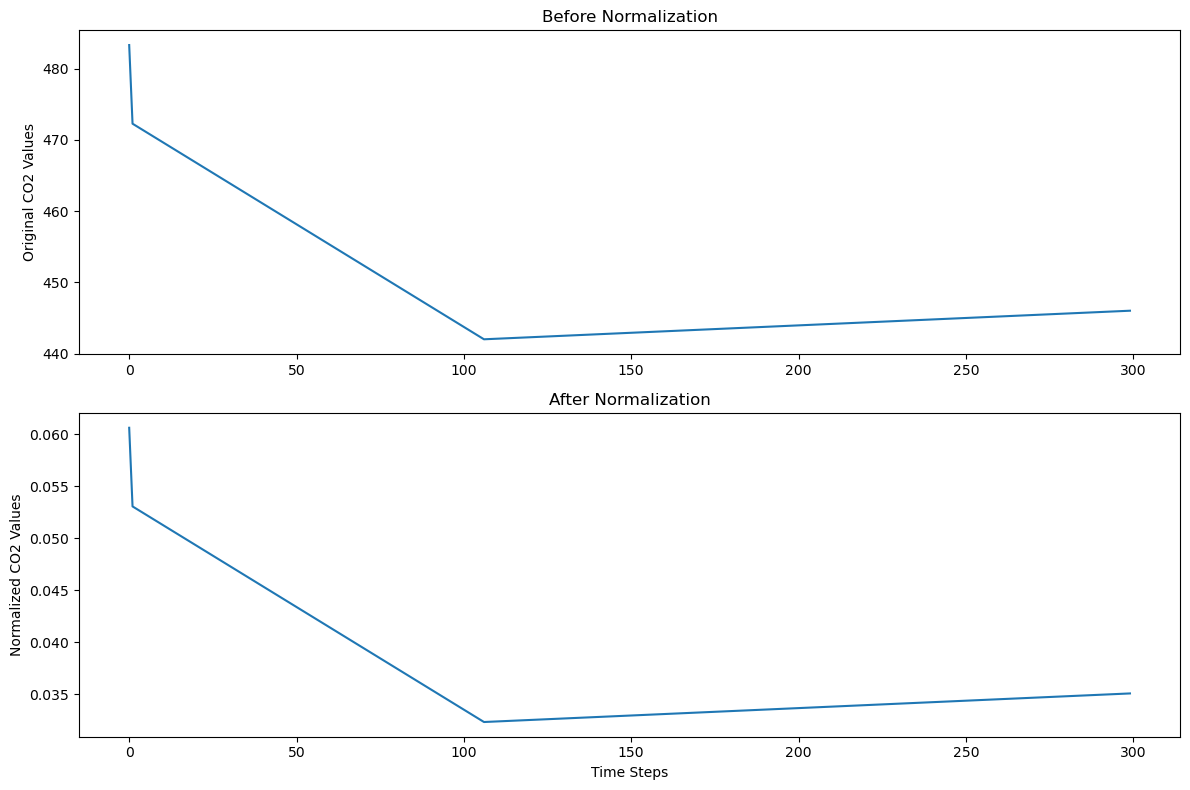

Train data sample:
 [[0.01361779 0.00489285 1.         0.56612057 0.26130695 0.76827059
  0.06062847 0.0669873  0.25       1.         0.35689587 0.
  0.        ]
 [0.01361779 0.0031142  1.         0.56612057 0.29371715 0.76016298
  0.05306865 0.01703709 0.37059048 1.         0.35689587 0.
  0.        ]]


In [12]:
# Create scaler
scaler = MinMaxScaler()

# Fit ONLY on training data
train_data = scaler.fit_transform(train_data)

# Transform validation and test data
val_data = scaler.transform(val_data)

test_data = scaler.transform(test_data)


# Visualize Before and After Normalization

feature_index = FEATURES.index('scd41_co2')

fig, axes = plt.subplots(2, 1, figsize=(12,8))

# Before normalization
axes[0].plot(
    data[:300, feature_index]
)

axes[0].set_title("Before Normalization")

axes[0].set_ylabel("Original CO2 Values")

# After normalization
axes[1].plot(
    train_data[:300, feature_index]
)

axes[1].set_title("After Normalization")

axes[1].set_ylabel("Normalized CO2 Values")

axes[1].set_xlabel("Time Steps")

plt.tight_layout()

plt.show()


# Print sample values
print("Train data sample:\n", train_data[:2])

11.Create Time-Series Sequences

In [13]:
# Find index of target column
target_index = FEATURES.index(TARGET)

# Function to create sequences
def create_sequences(data, seq_length=24):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        # Input sequence (24 timesteps)
        X.append(data[i:i + seq_length])

        # Target value (next CO2)
        y.append(data[i + seq_length][target_index])

    return np.array(X), np.array(y)

# Create sequences
X_train, y_train = create_sequences(train_data)

X_val, y_val = create_sequences(val_data)

X_test, y_test = create_sequences(test_data)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17293, 24, 13)
y_train shape: (17293,)
X_val shape: (3686, 24, 13)
y_val shape: (3686,)
X_test shape: (3688, 24, 13)
y_test shape: (3688,)


12.Convert Data to PyTorch Tensors

In [14]:
# Convert training data
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Convert validation data
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Convert testing data
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Print tensor shapes
print("X_train tensor shape:", X_train.shape)
print("y_train tensor shape:", y_train.shape)

X_train tensor shape: torch.Size([17293, 24, 13])
y_train tensor shape: torch.Size([17293])


13.Create DataLoaders

In [15]:
# Create training DataLoader
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

# Create validation DataLoader
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)

# Create testing DataLoader
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

In [16]:
# Check one batch from training loader
for X_batch, y_batch in train_loader:

    print("Batch X shape:", X_batch.shape)

    print("Batch y shape:", y_batch.shape)

    break               

Batch X shape: torch.Size([32, 24, 13])
Batch y shape: torch.Size([32])


14.Model

In [17]:
# Positional Encoding Class
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):

        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return x

In [19]:
# Transformer Model
class TransformerModel(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):

        super(TransformerModel, self).__init__()

        # Input projection layer
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        # Transformer encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Final output layer
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):

        # Project input
        x = self.input_projection(x)

        # Add positional encoding
        x = self.positional_encoding(x)

        # Transformer encoder
        x = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Final prediction
        x = self.fc(x)

        return x.squeeze()

In [20]:
# Initialize Transformer model
model = TransformerModel(input_dim=13)

# Print model architecture
print(model)

TransformerModel(
  (input_projection): Linear(in_features=13, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


15.Define Loss Function and Optimizer

In [21]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of epochs
epochs = 10

print("Loss function and optimizer initialized successfully.")

Loss function and optimizer initialized successfully.


16. Train the Transformer Model

In [26]:
# Store training losses
train_losses = []

# Training loop
for epoch in range(epochs):

    # Set model to training mode
    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Add batch loss
        epoch_loss += loss.item()

    # Average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    # Print epoch result
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/10, Loss: 0.000522
Epoch 2/10, Loss: 0.000523
Epoch 3/10, Loss: 0.000487
Epoch 4/10, Loss: 0.000425
Epoch 5/10, Loss: 0.000449
Epoch 6/10, Loss: 0.000501
Epoch 7/10, Loss: 0.000396
Epoch 8/10, Loss: 0.000420
Epoch 9/10, Loss: 0.000424
Epoch 10/10, Loss: 0.000393


17.Evaluate the Transformer Model

In [28]:
  # Set model to evaluation mode
model.eval()

# Store predictions
predictions = []

# Disable gradient calculation
with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # Model predictions
        outputs = model(X_batch)

        predictions.extend(outputs.numpy())

# Convert predictions and targets to numpy arrays
predictions = np.array(predictions)

actual = y_test.numpy()

# Calculate evaluation metrics
mse = mean_squared_error(actual, predictions)

rmse = np.sqrt(mse)

mae = mean_absolute_error(actual, predictions)

# Print results
print("Transformer Model Evaluation Metrics")

print(f"MSE  : {mse:.6f}")

print(f"RMSE : {rmse:.6f}")

print(f"MAE  : {mae:.6f}")

Transformer Model Evaluation Metrics
MSE  : 0.000185
RMSE : 0.013603
MAE  : 0.009955


18.Visualize Actual vs Predicted CO₂ Values

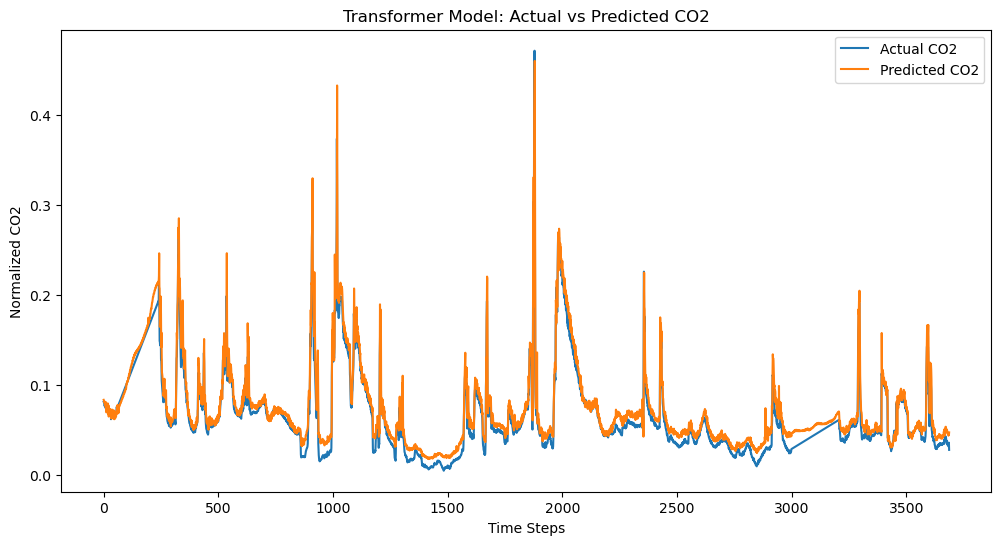

In [29]:
# Plot actual vs predicted values

plt.figure(figsize=(12, 6))

# Actual values
plt.plot(
    actual,
    label='Actual CO2'
)

# Predicted values
plt.plot(
    predictions,
    label='Predicted CO2'
)

# Graph labels
plt.title("Transformer Model: Actual vs Predicted CO2")

plt.xlabel("Time Steps")

plt.ylabel("Normalized CO2")

plt.legend()

plt.show()

Training Loss Visualization

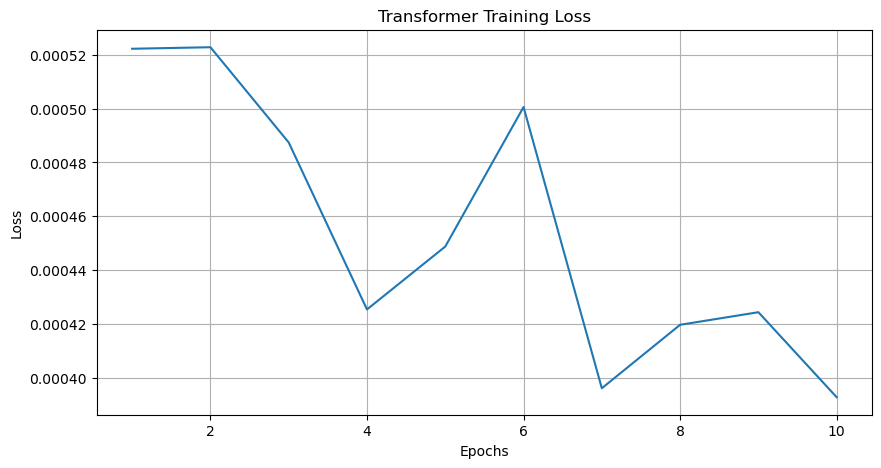

In [35]:
plt.figure(figsize=(10,5))

plt.plot(range(1, epochs + 1), train_losses)

plt.title("Transformer Training Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.grid(True)

plt.show()